# Manhattan Real Estate 2025 — Final Project - Gelara

**Dataset:** NYC Department of Finance Rolling Sales (Manhattan)
**Time period:** April 2025 – March 2026
**Source:** https://www.nyc.gov/site/finance/property/property-rolling-sales-data.page

## Questions I'll answer

1. How many neighborhoods are there, and which ones have the most transactions?
2. Which neighborhoods are the most expensive / cheapest?
3. How old are the buildings in each neighborhood?
4. Which months have the most sales?
5. Bonus: condo vs co-op price comparison
6. **Most expensive 10 sales of 2025 — plotted on a map**

## Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

### Load and clean the data

NYC's Excel file has 4 rows of header text before the actual data, so we skip them.

About 23% of "sales" in this file have `SALE PRICE = $0`. These are family transfers, deed corrections, LLC reorgs — not market transactions. We drop them up front.

In [5]:
df = pd.read_excel('rollingsales_manhattan.xlsx', skiprows=4)
df.columns = df.columns.str.strip()  # strip whitespace from column names

# Drop $0 and near-$0 transfers (not real market sales)
df = df[df['SALE PRICE'] >= 10000].copy()
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

print(f"Real transactions in dataset: {len(df):,}")
print(f"Date range: {df['SALE DATE'].min().date()} → {df['SALE DATE'].max().date()}")
df.head(3)

Real transactions in dataset: 14,867
Date range: 2025-04-01 → 2026-03-31


,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASEMENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,41,NaN,C6,"745 EAST 6TH STREET, 1B",NaN,...,28.0,0.0,28.0,4542.0,18254.0,1900.0,2,C4,540000,2025-12-17
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,389,22,NaN,C7,208 EAST 7TH STREET,NaN,...,28.0,2.0,30.0,4544.0,19418.0,1900.0,2,C7,8600000,2026-03-09
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,390,60,NaN,C2,191 EAST 7 STREET,NaN,...,5.0,0.0,5.0,1080.0,3328.0,1910.0,2,C2,4665000,2026-03-25


## Q1: How many neighborhoods, and which have the most transactions?

In [21]:
n_neighborhoods = df['NEIGHBORHOOD'].nunique()
print(f"Manhattan has {n_neighborhoods} neighborhoods in this dataset.\n")


neighborhoods = sorted(df['NEIGHBORHOOD'].unique())
for i, name in enumerate(neighborhoods, start=1):
    print(f"  {i:>2}. {name}")

Manhattan has 39 neighborhoods in this dataset.

   1. ALPHABET CITY
   2. CHELSEA
   3. CHINATOWN
   4. CIVIC CENTER
   5. CLINTON
   6. EAST VILLAGE
   7. FASHION
   8. FINANCIAL
   9. FLATIRON
  10. GRAMERCY
  11. GREENWICH VILLAGE-CENTRAL
  12. GREENWICH VILLAGE-WEST
  13. HARLEM-CENTRAL
  14. HARLEM-EAST
  15. HARLEM-UPPER
  16. HARLEM-WEST
  17. INWOOD
  18. JAVITS CENTER
  19. KIPS BAY
  20. LITTLE ITALY
  21. LOWER EAST SIDE
  22. MANHATTAN VALLEY
  23. MIDTOWN CBD
  24. MIDTOWN EAST
  25. MIDTOWN WEST
  26. MORNINGSIDE HEIGHTS
  27. MURRAY HILL
  28. ROOSEVELT ISLAND
  29. SOHO
  30. SOUTHBRIDGE
  31. TRIBECA
  32. UPPER EAST SIDE (59-79)
  33. UPPER EAST SIDE (79-96)
  34. UPPER EAST SIDE (96-110)
  35. UPPER WEST SIDE (59-79)
  36. UPPER WEST SIDE (79-96)
  37. UPPER WEST SIDE (96-116)
  38. WASHINGTON HEIGHTS LOWER
  39. WASHINGTON HEIGHTS UPPER


In [7]:
tx_counts = df['NEIGHBORHOOD'].value_counts()
print("Top 10:")
print(tx_counts.head(10))
print()
print("Bottom 5:")
print(tx_counts.tail(5))

Top 10:
NEIGHBORHOOD
UPPER EAST SIDE (59-79)      1622
UPPER EAST SIDE (79-96)      1401
UPPER WEST SIDE (59-79)      1283
MIDTOWN EAST                 1053
UPPER WEST SIDE (79-96)       860
CHELSEA                       729
MIDTOWN WEST                  674
SOHO                          569
GREENWICH VILLAGE-CENTRAL     544
GREENWICH VILLAGE-WEST        540
Name: count, dtype: int64

Bottom 5:
NEIGHBORHOOD
LITTLE ITALY                61
CHINATOWN                   60
ROOSEVELT ISLAND            59
UPPER EAST SIDE (96-110)    40
HARLEM-WEST                 17
Name: count, dtype: int64


### Visualize: bar chart with color by transaction volume

Darker color = more transactions.

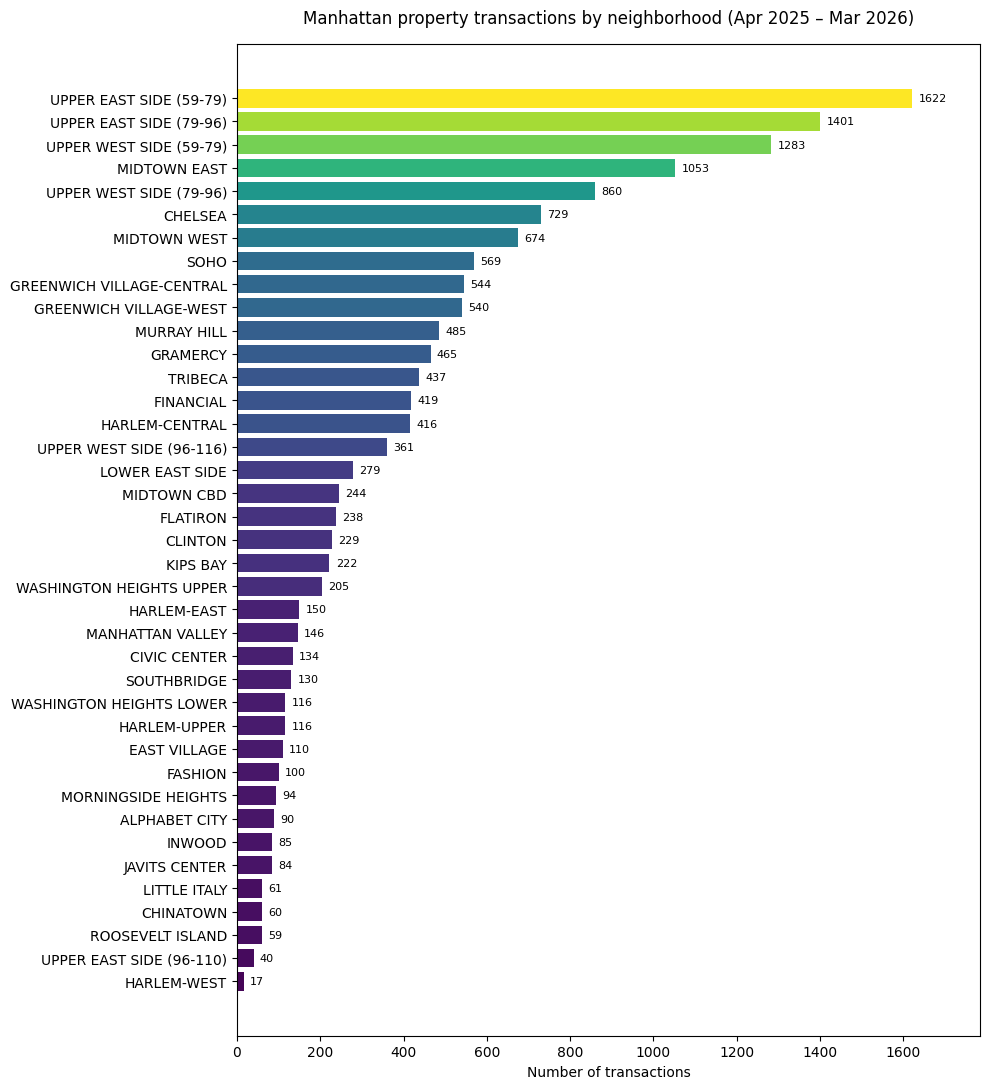

In [8]:
# Sort ascending so the longest bars sit at the top
counts_sorted = tx_counts.sort_values()

# Color by value: viridis colormap, lighter = fewer, darker = more
colors = plt.cm.viridis(counts_sorted.values / counts_sorted.values.max())

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(counts_sorted.index, counts_sorted.values, color=colors)

# Label each bar with its number
for bar, value in zip(bars, counts_sorted.values):
    ax.text(value + 15, bar.get_y() + bar.get_height()/2,
            str(value), va='center', fontsize=8)

ax.set_xlabel('Number of transactions')
ax.set_title('Manhattan property transactions by neighborhood (Apr 2025 – Mar 2026)',
             fontsize=12, pad=15)
ax.set_xlim(0, counts_sorted.max() * 1.1)
plt.tight_layout()
plt.show()

**Findings:**
- Upper East Side dominates — combined 59-79 + 79-96 = ~3,000 transactions.
- Upper West Side is second.
- Chelsea is #6 with 729 transactions — solid, but not the leader.
- Fewest: Harlem-West (17), Upper East Side 96-110 (40), Roosevelt Island (59).

## Q2: Most expensive vs cheapest neighborhood

We use **median** instead of mean because Manhattan has $1B+ outlier sales that wreck averages.

For a fair comparison, we restrict this analysis to **residential condos and co-ops only** — actual apartments people live in. We exclude condo-hotels, condo-offices, condo-storage units, and pure commercial properties because they're priced totally differently (some hotels in this dataset sell for $170M).

We also need to filter out one weird bulk transfer: 64 units at "1 Park Row" all recorded with the same $77M price (one deal recorded 64 times). We drop those.

In [9]:
# Keep only residential condos and coops
residential = df[
    df['BUILDING CLASS CATEGORY'].str.contains('CONDOS|COOPS', na=False) &
    ~df['BUILDING CLASS CATEGORY'].str.contains('HOTEL|OFFICE|STORE|STORAGE|NON-BUSINESS', na=False)
].copy()

# Remove the 1 Park Row bulk-transfer artifact
residential = residential[residential['SALE PRICE'] != 77002366]

print(f"Residential sales after filtering: {len(residential):,}")

Residential sales after filtering: 12,836


In [10]:
# Median price per neighborhood, only neighborhoods with 30+ sales (for reliable medians)
counts = residential['NEIGHBORHOOD'].value_counts()
reliable = counts[counts >= 30].index

median_price = residential[residential['NEIGHBORHOOD'].isin(reliable)] \
    .groupby('NEIGHBORHOOD')['SALE PRICE'].median().sort_values(ascending=False)

print("MOST EXPENSIVE (top 5):")
print(median_price.head().apply(lambda x: f"${x:,.0f}"))
print()
print("CHEAPEST (bottom 5):")
print(median_price.tail().apply(lambda x: f"${x:,.0f}"))

MOST EXPENSIVE (top 5):
NEIGHBORHOOD
SOHO             $3,571,000
JAVITS CENTER    $3,250,000
CIVIC CENTER     $3,200,000
TRIBECA          $2,695,000
LITTLE ITALY     $2,600,000
Name: SALE PRICE, dtype: object

CHEAPEST (bottom 5):
NEIGHBORHOOD
HARLEM-EAST                 $593,811
WASHINGTON HEIGHTS LOWER    $527,000
WASHINGTON HEIGHTS UPPER    $509,500
INWOOD                      $420,000
HARLEM-UPPER                $418,010
Name: SALE PRICE, dtype: object


### Visualize: cheapest 8 vs most expensive 8

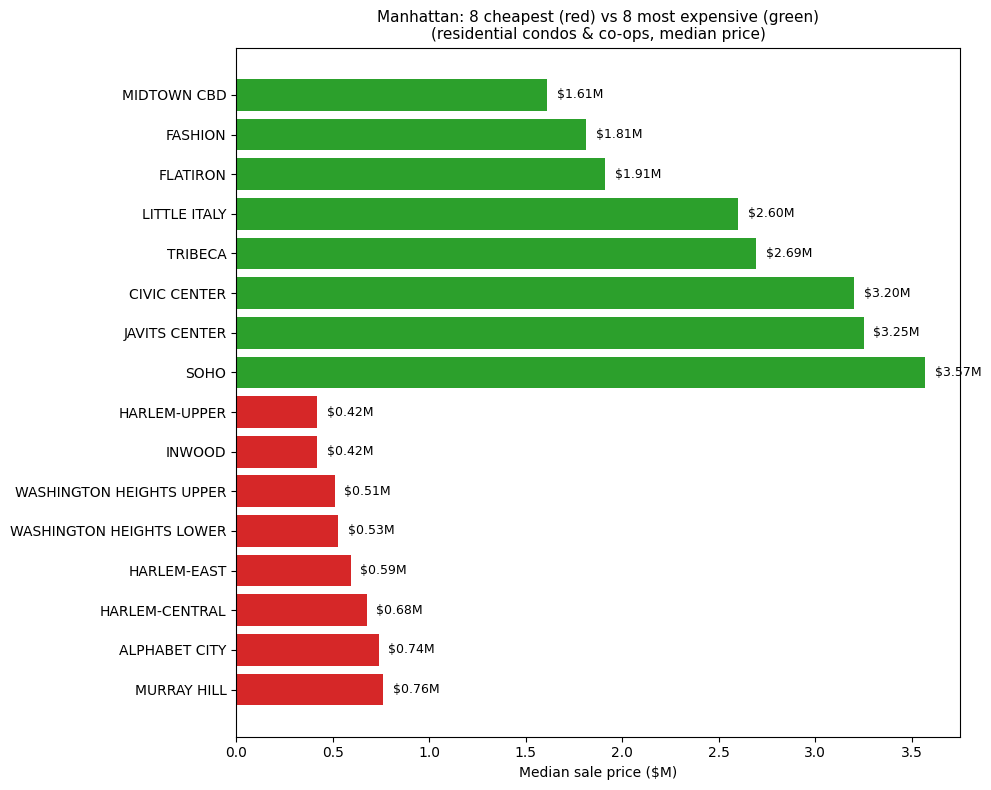

In [11]:
top8 = median_price.head(8)
bot8 = median_price.tail(8)
combined = pd.concat([bot8, top8])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728'] * 8 + ['#2ca02c'] * 8  # red = cheap, green = expensive
ax.barh(combined.index, combined.values / 1_000_000, color=colors)

for i, v in enumerate(combined.values):
    ax.text(v/1_000_000 + 0.05, i, f'${v/1_000_000:.2f}M', va='center', fontsize=9)

ax.set_xlabel('Median sale price ($M)')
ax.set_title('Manhattan: 8 cheapest (red) vs 8 most expensive (green)\n(residential condos & co-ops, median price)',
             fontsize=11)
plt.tight_layout()
plt.show()

**Findings:**
- **Most expensive:** SoHo, Tribeca, Greenwich Village, Flatiron, Midtown West (~$2-3.5M median).
- **Cheapest:** Harlem-West, Harlem-Upper, Inwood, Washington Heights ($300k-540k).
- The gap between most and least expensive is roughly **10×**.

## Q3: Average year built per neighborhood

How old is the typical building in each neighborhood? We filter out rows with `YEAR BUILT = 0` (missing).

In [12]:
yb = df[df['YEAR BUILT'] > 1700]
avg_year = yb.groupby('NEIGHBORHOOD')['YEAR BUILT'].mean().sort_values()

print("OLDEST building stock:")
print(avg_year.head().apply(lambda x: f"{x:.0f}"))
print()
print("NEWEST building stock:")
print(avg_year.tail().apply(lambda x: f"{x:.0f}"))

OLDEST building stock:
NEIGHBORHOOD
HARLEM-WEST                 1909
HARLEM-UPPER                1916
WASHINGTON HEIGHTS LOWER    1921
LITTLE ITALY                1929
UPPER WEST SIDE (96-116)    1932
Name: YEAR BUILT, dtype: object

NEWEST building stock:
NEIGHBORHOOD
HARLEM-EAST         1979
SOHO                1980
ROOSEVELT ISLAND    1987
SOUTHBRIDGE         1996
JAVITS CENTER       2003
Name: YEAR BUILT, dtype: object


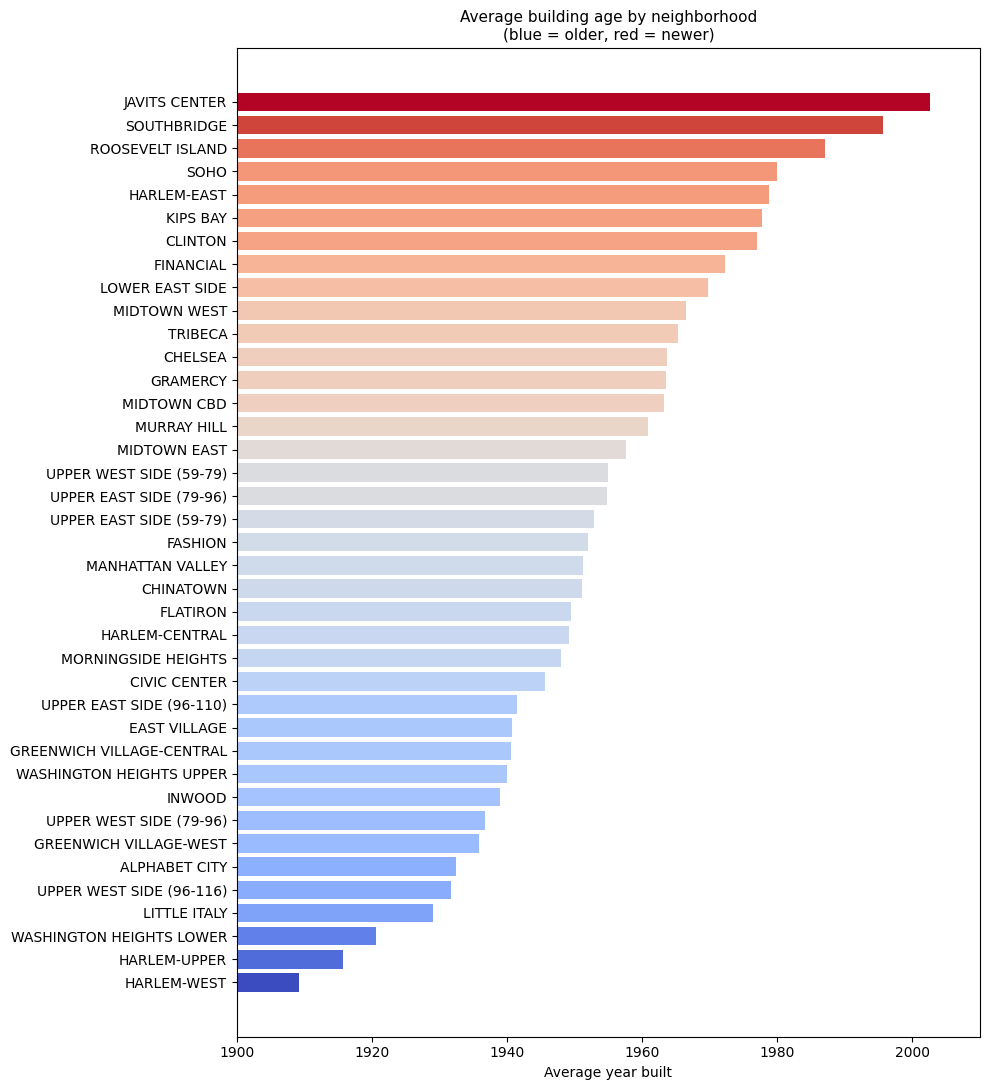

In [13]:
# Plot all neighborhoods, blue = older, red = newer
sorted_year = avg_year.sort_values()
norm = (sorted_year.values - sorted_year.min()) / (sorted_year.max() - sorted_year.min())
colors = plt.cm.coolwarm(norm)

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(sorted_year.index, sorted_year.values, color=colors)
ax.set_xlabel('Average year built')
ax.set_title('Average building age by neighborhood\n(blue = older, red = newer)',
             fontsize=11)
ax.set_xlim(1900, 2010)
plt.tight_layout()
plt.show()

**Findings:**
- Oldest stock: Harlem and Washington Heights (avg ~1910s — pre-war buildings).
- Newest: Javits Center, Southbridge, Roosevelt Island, SoHo, Harlem-East (planned developments / redevelopment zones).
- Most established neighborhoods average 1920s-1940s — the classic Manhattan apartment building era.

## Q4: Which months have the most transactions?

In [14]:
monthly = df.groupby(df['SALE DATE'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)

print("Transactions per month:")
for m, v in monthly.items():
    bar = '█' * int(v / 50)
    print(f"  {m}  {v:>5,}  {bar}")

Transactions per month:
  2025-04  1,162  ███████████████████████
  2025-05  1,213  ████████████████████████
  2025-06  1,403  ████████████████████████████
  2025-07  1,432  ████████████████████████████
  2025-08  1,356  ███████████████████████████
  2025-09  1,314  ██████████████████████████
  2025-10  1,515  ██████████████████████████████
  2025-11    962  ███████████████████
  2025-12  1,258  █████████████████████████
  2026-01  1,146  ██████████████████████
  2026-02    989  ███████████████████
  2026-03  1,117  ██████████████████████


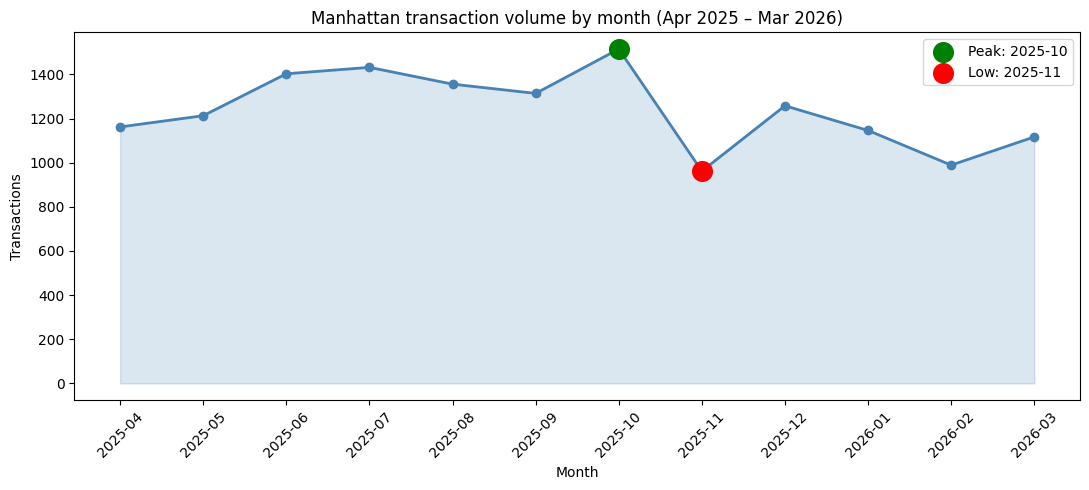

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2, color='steelblue')
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='steelblue')

# Highlight peak and low
peak_idx = monthly.values.argmax()
low_idx = monthly.values.argmin()
ax.scatter([monthly.index[peak_idx]], [monthly.values[peak_idx]],
           color='green', s=200, zorder=5, label=f'Peak: {monthly.index[peak_idx]}')
ax.scatter([monthly.index[low_idx]], [monthly.values[low_idx]],
           color='red', s=200, zorder=5, label=f'Low: {monthly.index[low_idx]}')

ax.set_xlabel('Month')
ax.set_ylabel('Transactions')
ax.set_title('Manhattan transaction volume by month (Apr 2025 – Mar 2026)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings:**
- October 2025 was the peak (~1,500 transactions).
- November 2025 dropped to the low (~960) — sharp month-over-month drop worth noting.
- Summer (June–August) is consistently strong.
- Winter (January-February) is the quiet season.

## Q5 (Bonus): Condo vs Co-op — which costs more?

NYC lore says condos cost more than co-ops because they have fewer ownership restrictions. Let's check.

In [16]:
def categorize(cat):
    if 'CONDOS' in cat:
        return 'Condo'
    elif 'COOPS' in cat:
        return 'Co-op'
    return None

residential['type'] = residential['BUILDING CLASS CATEGORY'].apply(categorize)

print("Overall medians:")
overall = residential.groupby('type')['SALE PRICE'].agg(['count', 'median'])
overall['median'] = overall['median'].map(lambda v: f"${v:,.0f}")
print(overall)

Overall medians:
       count      median
type                    
Co-op   6993    $845,000
Condo   5843  $1,660,000


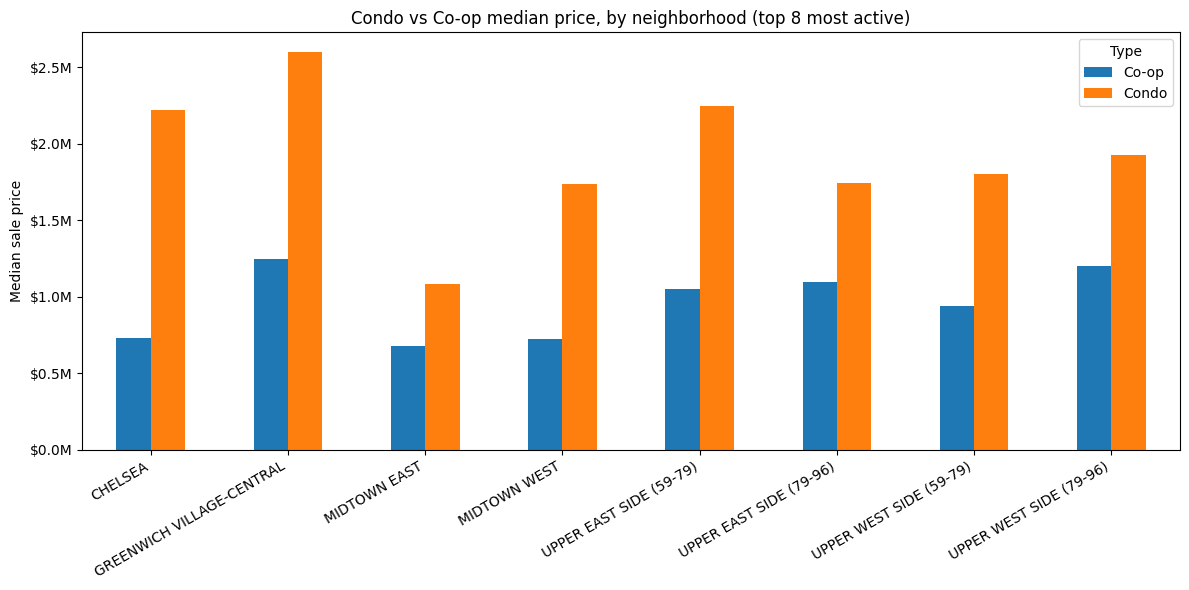

In [17]:
# Side-by-side comparison for the top 8 most active neighborhoods
top_nbhds = residential['NEIGHBORHOOD'].value_counts().head(8).index
comparison = residential[residential['NEIGHBORHOOD'].isin(top_nbhds)] \
    .groupby(['NEIGHBORHOOD', 'type'])['SALE PRICE'].median().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
comparison.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_ylabel('Median sale price')
ax.set_title('Condo vs Co-op median price, by neighborhood (top 8 most active)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=30, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

**Confirmed:** condos sell for considerably more than co-ops in every major neighborhood — typically 1.5× to 2× the price. Conventional wisdom holds.

## Q6 (Fun finale): The 10 most expensive sales of 2025 — on a map

What were Manhattan's biggest deals this year? Let's find them and plot them.

### Step 1: Find the top 10

There's a wrinkle: large commercial deals often get recorded multiple times — once per unit, all with the same total price. So if we just take the raw top 10, we'd get duplicates of the same building. We dedupe by `(address, price)` first.

In [18]:
# Strip apartment/unit info from address (everything after the first comma)
df['street_address'] = df['ADDRESS'].str.split(',').str[0].str.strip()

# Same address + same price = same deal recorded multiple times. Keep one row each.
unique_sales = df.drop_duplicates(subset=['street_address', 'SALE PRICE'])

# Take top 10
top10 = unique_sales.nlargest(10, 'SALE PRICE').reset_index(drop=True)
top10[['street_address', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'SALE PRICE', 'SALE DATE']]

,street_address,NEIGHBORHOOD,BUILDING CLASS CATEGORY,SALE PRICE,SALE DATE
0,590 MADISON AVENUE,MIDTOWN CBD,21 OFFICE BUILDINGS,1080000000,2025-08-14
1,9 EAST 56 STREET,MIDTOWN CBD,22 STORE BUILDINGS,1080000000,2025-08-14
2,8 EAST 57 STREET,MIDTOWN CBD,22 STORE BUILDINGS,1080000000,2025-08-14
3,800 5 AVENUE,UPPER EAST SIDE (59-79),08 RENTALS - ELEVATOR APARTMENTS,810000000,2025-08-14
4,1177 AVENUE OF THE AMER,MIDTOWN WEST,21 OFFICE BUILDINGS,572290334,2025-09-15
5,1334 YORK AVENUE,UPPER EAST SIDE (59-79),43 CONDO OFFICE BUILDINGS,510000000,2025-10-01
6,650 FIFTH AVENUE,MIDTOWN WEST,21 OFFICE BUILDINGS,435000000,2026-03-18
7,557 BROADWAY,SOHO,21 OFFICE BUILDINGS,386000000,2025-12-17
8,549 BROADWAY,SOHO,21 OFFICE BUILDINGS,386000000,2025-12-17
9,522 5 AVENUE,MIDTOWN WEST,43 CONDO OFFICE BUILDINGS,340000000,2025-05-01


### Step 2: Add latitude / longitude for each address

Our dataset doesn't include lat/lon, so we add them. Two approaches in the code below — try the geocoder first, fall back to a manual lookup dict if that fails.

In [19]:
# --- Manual coordinate lookup (reliable backup, no internet needed) ---
# These were looked up on Google Maps for the top 10 most expensive deals.
KNOWN_COORDS = {
    "590 MADISON AVENUE":      (40.7625, -73.9722),
    "9 EAST 56 STREET":        (40.7619, -73.9737),
    "8 EAST 57 STREET":        (40.7628, -73.9728),
    "800 5 AVENUE":            (40.7660, -73.9710),
    "1177 AVENUE OF THE AMER": (40.7587, -73.9826),
    "1334 YORK AVENUE":        (40.7686, -73.9531),
    "650 FIFTH AVENUE":        (40.7588, -73.9772),
    "557 BROADWAY":            (40.7237, -73.9989),
    "549 BROADWAY":            (40.7234, -73.9990),
    "522 5 AVENUE":            (40.7541, -73.9806),
}

# --- Try real geocoding first (geopy/Nominatim). If it fails, use KNOWN_COORDS. ---
# If geopy isn't installed, run in a terminal: pip install geopy
try:
    from geopy.geocoders import Nominatim
    import time
    geolocator = Nominatim(user_agent="manhattan_real_estate_class_project")
    
    def geocode(address):
        try:
            loc = geolocator.geocode(f"{address}, Manhattan, New York, NY", timeout=10)
            if loc:
                return loc.latitude, loc.longitude
        except Exception:
            pass
        return None, None
    
    geocoder_works = True
except ImportError:
    geocoder_works = False
    print("geopy not installed — falling back to manual coordinates.")

lats, lons = [], []
for addr in top10['street_address']:
    lat, lon = (None, None)
    if geocoder_works:
        lat, lon = geocode(addr)
        time.sleep(1)  # Nominatim rate limit: 1 req/sec
    # If geocoding didn't return anything, use the manual fallback
    if lat is None and addr in KNOWN_COORDS:
        lat, lon = KNOWN_COORDS[addr]
    print(f"  {addr:<30} → ({lat}, {lon})")
    lats.append(lat)
    lons.append(lon)

top10['latitude'] = lats
top10['longitude'] = lons

geopy not installed — falling back to manual coordinates.
  590 MADISON AVENUE             → (40.7625, -73.9722)
  9 EAST 56 STREET               → (40.7619, -73.9737)
  8 EAST 57 STREET               → (40.7628, -73.9728)
  800 5 AVENUE                   → (40.766, -73.971)
  1177 AVENUE OF THE AMER        → (40.7587, -73.9826)
  1334 YORK AVENUE               → (40.7686, -73.9531)
  650 FIFTH AVENUE               → (40.7588, -73.9772)
  557 BROADWAY                   → (40.7237, -73.9989)
  549 BROADWAY                   → (40.7234, -73.999)
  522 5 AVENUE                   → (40.7541, -73.9806)


  9 EAST 56 STREET               → (40.7619, -73.9737)


  8 EAST 57 STREET               → (40.7628, -73.9728)


  800 5 AVENUE                   → (40.766, -73.971)


  1177 AVENUE OF THE AMER        → (40.7587, -73.9826)


  1334 YORK AVENUE               → (40.7686, -73.9531)


  650 FIFTH AVENUE               → (40.7588, -73.9772)


  557 BROADWAY                   → (40.7237, -73.9989)


  549 BROADWAY                   → (40.7234, -73.999)


  522 5 AVENUE                   → (40.7541, -73.9806)


### Step 3: Plot the map (using teacher's Folium style)

In [20]:
import folium

fig = folium.Figure(width=900, height=550)
m = folium.Map(location=(40.7580, -73.9855), zoom_start=13)  # Midtown center

for idx, row in top10.iterrows():
    if pd.isna(row['latitude']):
        continue  # skip if no coordinates
    
    price_m = row['SALE PRICE'] / 1_000_000
    rank = idx + 1
    
    folium.Marker(
        location=(row['latitude'], row['longitude']),
        tooltip=f"#{rank}: ${price_m:.0f}M — {row['street_address']}",
        popup=f"<b>#{rank} — ${row['SALE PRICE']:,.0f}</b><br>"
              f"{row['street_address']}<br>"
              f"{row['NEIGHBORHOOD']}<br>"
              f"<i>{row['BUILDING CLASS CATEGORY']}</i><br>"
              f"Sold: {row['SALE DATE'].date()}",
        icon=folium.Icon(icon="star", color="red")
    ).add_to(m)

fig.add_child(m)

**Findings:**
- The top 3 deals are all $1.08B at three Midtown addresses (590 Madison, 9 E 56, 8 E 57) — likely a single portfolio deal recorded across three buildings.
- Most of the biggest deals cluster in **Midtown** — that's where the trophy office buildings and luxury Fifth Avenue retail are.
- Two SoHo deals at $386M each (557 and 549 Broadway) — landmark cast-iron buildings on a single block.
- Hover over each marker to see the rank and price; click to see full details.

## Summary

1. **Volume:** Upper East Side dominates Manhattan deal volume; Chelsea is solid at #6.
2. **Price:** SoHo, Tribeca, and Greenwich Village are most expensive (~$2-3.5M median). Harlem and Washington Heights are cheapest ($300-540k). About a 10× gap.
3. **Building age:** Oldest in Harlem and Washington Heights (~1910s); newest in planned developments. Location matters more than age for price.
4. **Timing:** October was the peak month; November dropped sharply. Summer is consistently busy.
5. **Condo vs co-op:** Condos cost ~1.5–2× more in every major neighborhood.
6. **Biggest deals:** Manhattan saw three $1.08B deals in 2025, all clustered in Midtown — plus landmark sales in SoHo and on Fifth Avenue.

### Notes on data quality
- 23% of records had `SALE PRICE = $0` (family transfers, deed corrections) — dropped during cleaning.
